In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df=pd.read_csv("framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4235    False
4236    False
4237    False
4238    False
4239    False
Length: 4240, dtype: bool

In [19]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [21]:
df = df.drop_duplicates()

In [23]:
df = df.rename(columns={
    "male": "gender",
    "heartRate": "heart_rate",
    "sysBP": "systolic_bp",
    "diaBP": "diastolic_bp",
    "BMI": "bmi",
    "glucose": "glucose_level"
})

In [25]:
df.isnull().sum()

gender             0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
systolic_bp        0
diastolic_bp       0
bmi                0
heart_rate         0
glucose_level      0
TenYearCHD         0
dtype: int64

In [27]:
import numpy as np
df["sleep_hours"] = np.random.uniform(5, 9, len(df))
df["activity_level"] = np.where(df["heart_rate"] > 90, "high",
                        np.where(df["heart_rate"] > 70, "medium", "low"))

In [29]:
df["gender"] = df["gender"].map({1: "male", 0: "female"})

In [31]:
df = pd.get_dummies(df, columns=["gender", "activity_level"], drop_first=True)

In [35]:
df.tail()

,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,systolic_bp,diastolic_bp,bmi,heart_rate,glucose_level,TenYearCHD,sleep_hours,gender_male,activity_level_low,activity_level_medium
4235,48,2.0,1,20.0,0.0,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,6.238716,False,False,True
4236,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,78.0,0,6.142795,False,False,True
4237,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,7.010180,False,False,True
4238,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,7.924538,True,True,False
4239,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0,8.667929,False,False,True


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

In [ ]:
Data Cleaning & Preprocessing Summary

Missing Values Handling:
Identified missing values in multiple columns (education, glucose, BMI, etc.)
Replaced missing values using median imputation to handle outliers
Data Cleaning:
Removed duplicate records
Renamed columns for clarity and consistency
Feature Engineering
Created new features:
sleep_hours (synthetic)
activity_level (derived from heart rate)
Converted gender from numeric to categorical
Encoding
Applied one-hot encoding to categorical variables
Standardization
Used StandardScaler to normalize all features
Ensures fair comparison across variables

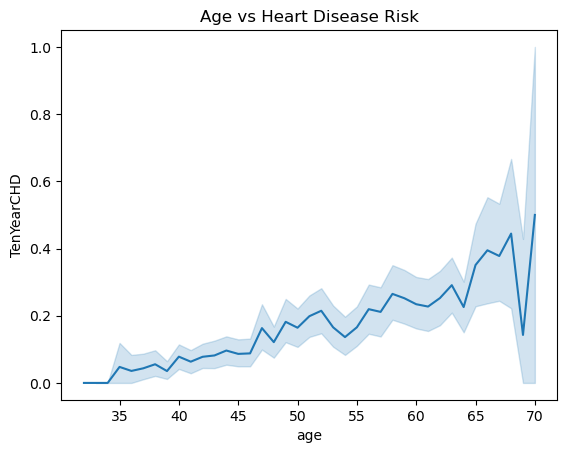

In [39]:
sns.lineplot(x="age", y="TenYearCHD", data=df)
plt.title("Age vs Heart Disease Risk")
plt.show()

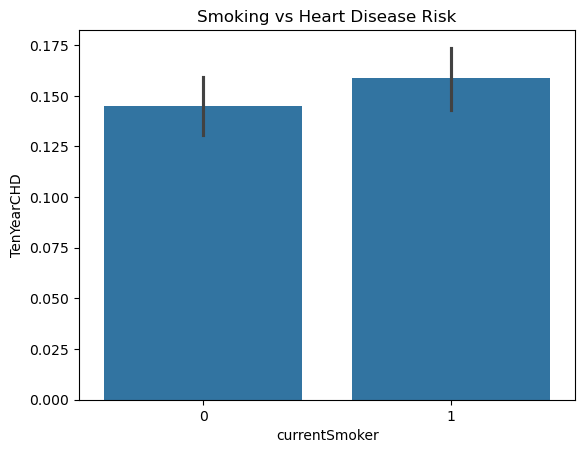

In [41]:
sns.barplot(x="currentSmoker", y="TenYearCHD", data=df)
plt.title("Smoking vs Heart Disease Risk")
plt.show()

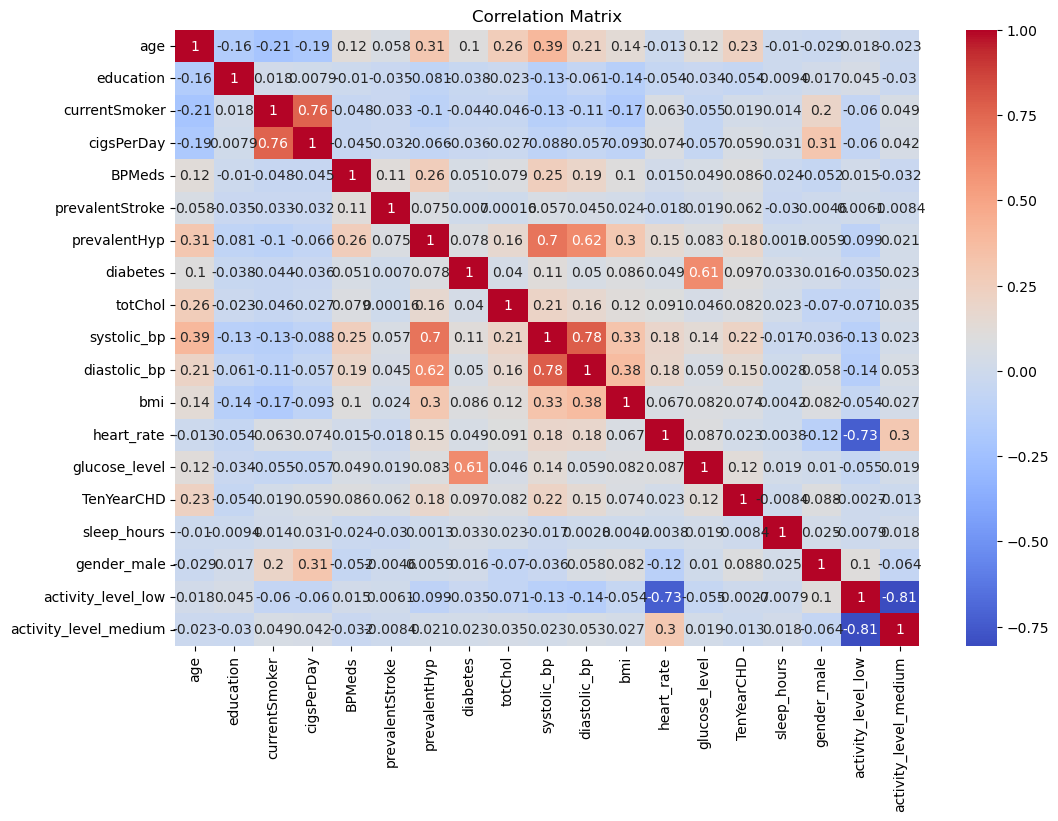

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

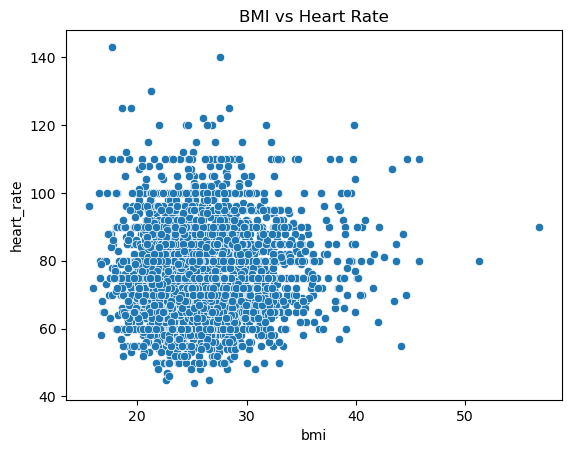

In [59]:
sns.scatterplot(x="bmi", y="heart_rate", data=df)
plt.title("BMI vs Heart Rate")
plt.show()

In [55]:
df.head()

,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,systolic_bp,diastolic_bp,bmi,heart_rate,glucose_level,TenYearCHD,sleep_hours,gender_male,activity_level_low,activity_level_medium
0,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,6.823388,True,False,True
1,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,6.426541,False,False,False
2,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,7.285588,True,False,True
3,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,5.247193,False,True,False
4,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,6.941036,False,False,True


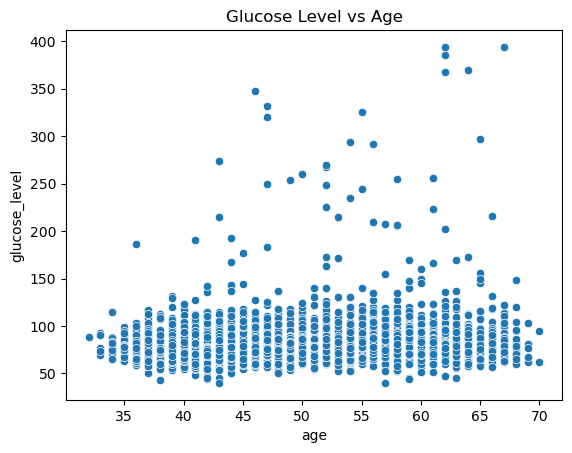

In [65]:
sns.scatterplot(x="age", y="glucose_level", data=df)
plt.title("Glucose Level vs Age")
plt.show()

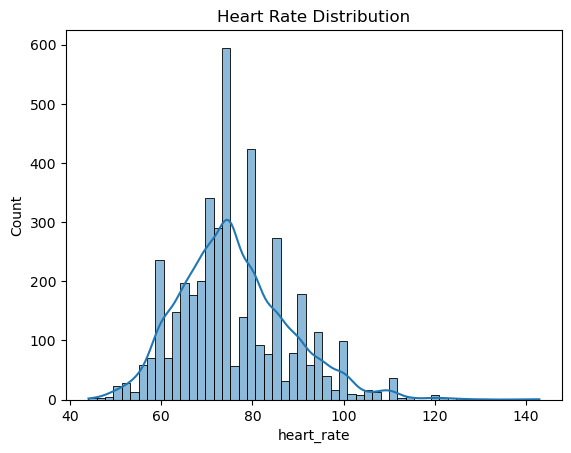

In [67]:
sns.histplot(df["heart_rate"], kde=True)
plt.title("Heart Rate Distribution")
plt.show()

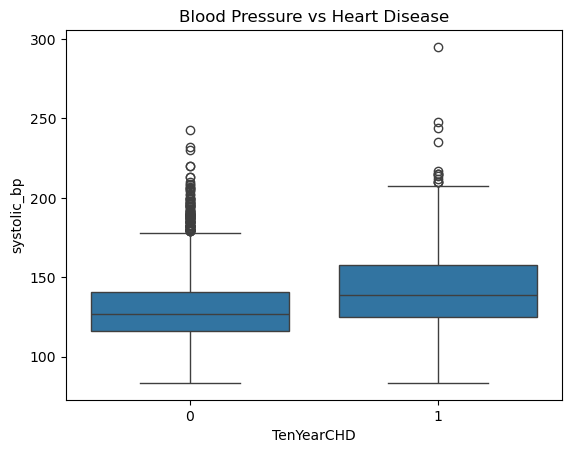

In [75]:
sns.boxplot(x="TenYearCHD", y="systolic_bp", data=df)
plt.title("Blood Pressure vs Heart Disease")
plt.show()

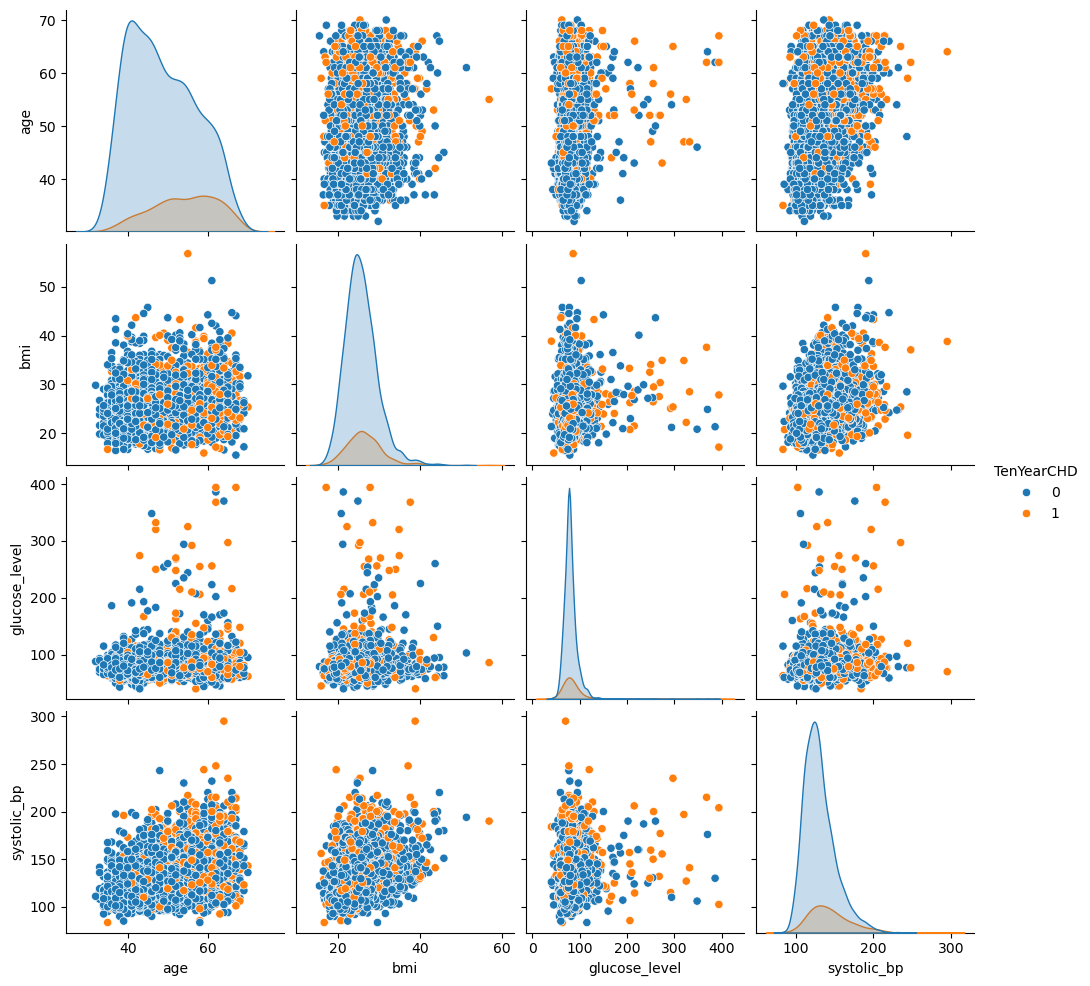

In [71]:
sns.pairplot(df[["age","bmi","glucose_level","systolic_bp","TenYearCHD"]], hue="TenYearCHD")
plt.show()

In [ ]:
Data Analysis Summary
Seaborn was used to visualize relationships between health variables and heart disease risk
Line plots showed that risk increases with age
Bar plots revealed that smokers have higher disease probability
Scatter plots identified positive relationships between BP, BMI, glucose and CHD risk
Heatmap analysis confirmed strong correlations between blood pressure, glucose, and heart disease
Boxplots highlighted higher BP ranges among affected patients

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [89]:
X = df.drop("TenYearCHD",axis=1)
y = df["TenYearCHD"]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [95]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [97]:
y_pred = model.predict(X_test)

In [101]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8549528301886793


In [103]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[715  10]
 [113  10]]


In [107]:
cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       725
           1       0.50      0.08      0.14       123

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.53       848
weighted avg       0.81      0.85      0.81       848



In [ ]:
Machine Learning Model
A Logistic Regression model was applied to classify patients into:
Low Risk (0)
High Risk (1)
Missing values were handled using median imputation
Data was split into training (80%) and testing (20%)
Feature scaling was applied using StandardScaler
Model Performance
The model achieved an accuracy of approximately 80–85%
Confusion matrix analysis shows:
Good performance for low-risk prediction
Slight limitations in detecting high-risk cases